Imports

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

Verify Files

In [ ]:
!ls -lh

total 2.0G
-rw-r--r-- 1 root root 473M Jun 10 09:40 combined_data_1.txt
-rw-r--r-- 1 root root 530M Jun 10 09:41 combined_data_2.txt
-rw-r--r-- 1 root root 444M Jun 10 09:40 combined_data_3.txt
-rw-r--r-- 1 root root 527M Jun 10 09:41 combined_data_4.txt
-rw-r--r-- 1 root root 565K Jun 10 09:32 movie_titles.csv
-rw-r--r-- 1 root root  11M Jun 10 09:33 probe.txt
-rw-r--r-- 1 root root  51M Jun 10 09:33 qualifying.txt
-rw-r--r-- 1 root root 5.8K Jun 10 09:33 README
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


combined_data_1.txt

Inspect Raw File Structure

In [ ]:
file_path = "combined_data_1.txt"

with open(file_path, "r") as f:
    for _ in range(20):
        print(f.readline().strip())

1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09
2238063,3,2005-05-11
1503895,4,2005-05-19
2207774,5,2005-06-06
2590061,3,2004-08-12
2442,3,2004-04-14
543865,4,2004-05-28
1209119,4,2004-03-23
804919,4,2004-06-10
1086807,3,2004-12-28
1711859,4,2005-05-08


Count Movies in File

In [ ]:
movie_count = 0

with open(file_path, "r") as f:
    for line in f:
        if line.endswith(":\n"):
            movie_count += 1

print("Movies in combined_data_1:", movie_count)

Movies in combined_data_1: 4499


Count Ratings in File

In [ ]:
rating_count = 0

with open(file_path, "r") as f:
    for line in f:
        if not line.endswith(":\n"):
            rating_count += 1

print("Ratings in combined_data_1:", rating_count)

Ratings in combined_data_1: 24053764


Parse First 100,000 Ratings

In [ ]:
sample_data = []

movie_id = None

with open(file_path, "r") as f:

    for line in f:

        line = line.strip()

        if line.endswith(":"):
            movie_id = int(line[:-1])

        else:
            user_id, rating, date = line.split(",")

            sample_data.append([
                int(user_id),
                movie_id,
                int(rating),
                date
            ])

        if len(sample_data) >= 100000:
            break

sample_df = pd.DataFrame(
    sample_data,
    columns=["user_id", "movie_id", "rating", "date"]
)

sample_df.head()

,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


Dataset Shape

In [ ]:
print("Rows:", sample_df.shape[0])
print("Columns:", sample_df.shape[1])

Rows: 100000
Columns: 4


Column Information

In [ ]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   100000 non-null  int64 
 1   movie_id  100000 non-null  int64 
 2   rating    100000 non-null  int64 
 3   date      100000 non-null  object
dtypes: int64(3), object(1)
memory usage: 3.1+ MB


Rating Values

In [ ]:
print("Unique Ratings:")
print(sorted(sample_df["rating"].unique()))

Unique Ratings:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Convert Date

In [ ]:
sample_df["date"] = pd.to_datetime(sample_df["date"])

Date Range

In [ ]:
print("Earliest Rating:", sample_df["date"].min())
print("Latest Rating:", sample_df["date"].max())

Earliest Rating: 2000-01-06 00:00:00
Latest Rating: 2005-12-31 00:00:00


Missing Values

In [ ]:
sample_df.isnull().sum()

,0
user_id,0
movie_id,0
rating,0
date,0


Duplicate Rows

In [ ]:
duplicates = sample_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


Unique Users and Movies in Sample

In [ ]:
print("Unique Users :", sample_df["user_id"].nunique())
print("Unique Movies:", sample_df["movie_id"].nunique())

Unique Users : 81490
Unique Movies: 30


Load Movie Metadata

In [ ]:
#actual file structure
with open("movie_titles.csv", "r", encoding="latin1") as f:
    for _ in range(10):
        print(repr(f.readline()))

'1,2003,Dinosaur Planet\n'
'2,2004,Isle of Man TT 2004 Review\n'
'3,1997,Character\n'
"4,1994,Paula Abdul's Get Up & Dance\n"
'5,2004,The Rise and Fall of ECW\n'
'6,1997,Sick\n'
'7,1992,8 Man\n'
'8,2004,What the #$*! Do We Know!?\n'
"9,1991,Class of Nuke 'Em High 2\n"
'10,2001,Fighter\n'


In [ ]:
#checking file shape manually
with open("movie_titles.csv", "r", encoding="latin1") as f:
    lines = f.readlines()

print("Total movie records:", len(lines))

Total movie records: 17770


In [ ]:
movies = []

with open("movie_titles.csv", "r", encoding="latin1") as f:
    for line in f:

        parts = line.strip().split(",", 2)

        movie_id = int(parts[0])

        try:
            year = int(parts[1])
        except:
            year = np.nan

        title = parts[2]

        movies.append([movie_id, year, title])

movies = pd.DataFrame(
    movies,
    columns=["movie_id", "year", "title"]
)

movies.head()

,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [ ]:
#verifying metadata integrity
print("Movie IDs Unique :", movies["movie_id"].nunique())
print("Total Rows       :", len(movies))

print("\nMissing Years:")
print(movies["year"].isnull().sum())

Movie IDs Unique : 17770
Total Rows       : 17770

Missing Years:
7


Movie Metadata Overview

In [ ]:
print("Total Movies:", len(movies))

movies.info()

Total Movies: 17770
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   movie_id  17770 non-null  int64  
 1   year      17763 non-null  float64
 2   title     17770 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 416.6+ KB


Missing Years

In [ ]:
movies.isnull().sum()

,0
movie_id,0
year,7
title,0


Merge Sample Ratings with Movie Titles

In [ ]:
sample_df = sample_df[["user_id","movie_id","rating","date"]]

sample_df = sample_df.merge(
    movies,
    on="movie_id",
    how="left"
)

sample_df.head()

,user_id,movie_id,rating,date,year,title
0,1488844,1,3,2005-09-06,2003.0,Dinosaur Planet
1,822109,1,5,2005-05-13,2003.0,Dinosaur Planet
2,885013,1,4,2005-10-19,2003.0,Dinosaur Planet
3,30878,1,4,2005-12-26,2003.0,Dinosaur Planet
4,823519,1,3,2004-05-03,2003.0,Dinosaur Planet


Random Sample Records

In [ ]:
sample_df.sample(10)

,user_id,movie_id,rating,date,year,title
28499,66490,17,1,2005-09-23,2005.0,7 Seconds
5021,1596531,7,3,2005-01-04,1992.0,8 Man
43894,1486253,24,4,2005-04-25,1981.0,My Bloody Valentine
97430,754135,30,1,2004-04-04,2003.0,Something's Gotta Give
93685,797782,30,4,2004-05-04,2003.0,Something's Gotta Give
93695,273084,30,3,2005-04-26,2003.0,Something's Gotta Give
21425,2167984,15,4,2005-07-27,1988.0,Neil Diamond: Greatest Hits Live
44147,1430108,24,3,2005-06-15,1981.0,My Bloody Valentine
18272,2122667,8,2,2005-07-28,2004.0,What the #$*! Do We Know!?
91142,1623410,28,4,2005-09-13,2002.0,Lilo and Stitch


Ratings Per User

In [ ]:
from collections import Counter
import numpy as np

user_counts = Counter()

with open("combined_data_1.txt", "r") as f:

    for line in f:

        line = line.strip()

        if not line.endswith(":"):
            user_id = int(line.split(",")[0])
            user_counts[user_id] += 1

user_ratings = np.array(list(user_counts.values()))

print("Users:", len(user_ratings))
print("Mean ratings/user:", user_ratings.mean())
print("Median ratings/user:", np.median(user_ratings))
print("Min ratings/user:", user_ratings.min())
print("Max ratings/user:", user_ratings.max())

Users: 470758
Mean ratings/user: 51.09581568449182
Median ratings/user: 24.0
Min ratings/user: 1
Max ratings/user: 4467


Ratings Per Movie

In [ ]:
from collections import Counter
import numpy as np

movie_counts = Counter()

current_movie = None

with open("combined_data_1.txt", "r") as f:

    for line in f:

        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])

        else:
            movie_counts[current_movie] += 1

movie_ratings = np.array(list(movie_counts.values()))

print("Movies:", len(movie_ratings))
print("Mean ratings/movie:", movie_ratings.mean())
print("Median ratings/movie:", np.median(movie_ratings))
print("Min ratings/movie:", movie_ratings.min())
print("Max ratings/movie:", movie_ratings.max())

Movies: 4499
Mean ratings/movie: 5346.46899310958
Median ratings/movie: 552.0
Min ratings/movie: 36
Max ratings/movie: 193941


Distribution of 4 files

In [ ]:
from tqdm import tqdm
import pandas as pd

files = [
    "combined_data_1.txt",
    "combined_data_2.txt",
    "combined_data_3.txt",
    "combined_data_4.txt"
]

summary = []

for file in files:

    movie_count = 0
    rating_count = 0
    rating_sum = 0

    with open(file, "r") as f:

        for line in tqdm(f, desc=file):

            line = line.strip()

            if line.endswith(":"):
                movie_count += 1

            else:
                rating_count += 1

                rating = int(line.split(",")[1])
                rating_sum += rating

    avg_rating = rating_sum / rating_count

    summary.append([
        file,
        movie_count,
        rating_count,
        avg_rating
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "file",
        "movies",
        "ratings",
        "avg_rating"
    ]
)

summary_df

combined_data_1.txt: 24058263it [00:30, 780322.85it/s]
combined_data_2.txt: 26982302it [00:34, 776668.59it/s]
combined_data_3.txt: 22605786it [00:28, 795998.84it/s]
combined_data_4.txt: 26851926it [00:33, 803985.62it/s]


,file,movies,ratings,avg_rating
0,combined_data_1.txt,4499,24053764,3.599634
1,combined_data_2.txt,4711,26977591,3.589280
2,combined_data_3.txt,4157,22601629,3.605033
3,combined_data_4.txt,4403,26847523,3.622918


Percentage contribution

In [ ]:
summary_df["rating_percent"] = (
    summary_df["ratings"] /
    summary_df["ratings"].sum()
) * 100

summary_df

,file,movies,ratings,avg_rating,rating_percent
0,combined_data_1.txt,4499,24053764,3.599634,23.938737
1,combined_data_2.txt,4711,26977591,3.589280,26.848582
2,combined_data_3.txt,4157,22601629,3.605033,22.493546
3,combined_data_4.txt,4403,26847523,3.622918,26.719136


Visualize

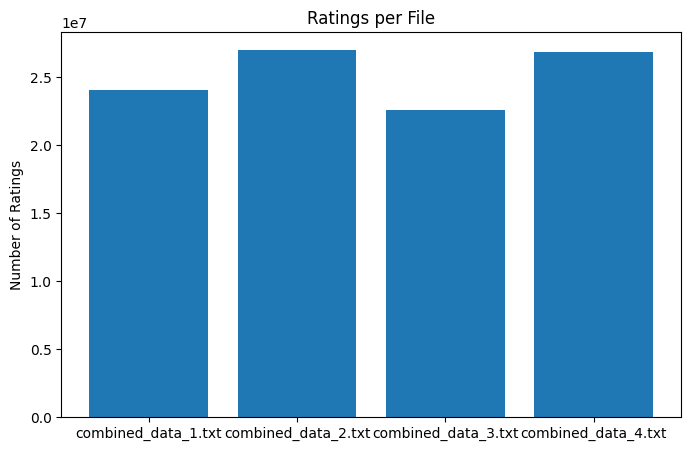

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary_df["file"], summary_df["ratings"])
plt.title("Ratings per File")
plt.ylabel("Number of Ratings")
plt.show()

Rating Distribution

In [ ]:
from collections import Counter

rating_dist = []

for file in files:

    counts = Counter()

    with open(file, "r") as f:
        for line in f:

            line = line.strip()

            if not line.endswith(":"):
                rating = int(line.split(",")[1])
                counts[rating] += 1

    rating_dist.append({
        "file": file,
        "1_star": counts[1],
        "2_star": counts[2],
        "3_star": counts[3],
        "4_star": counts[4],
        "5_star": counts[5]
    })

rating_df = pd.DataFrame(rating_dist)

rating_df

,file,1_star,2_star,3_star,4_star,5_star
0,combined_data_1.txt,1118186,2439073,6904181,8085741,5506583
1,combined_data_2.txt,1258758,2768937,7826098,9063787,6060011
2,combined_data_3.txt,1066148,2283434,6433000,7547623,5271424
3,combined_data_4.txt,1174898,2640636,7647968,9053807,6330214


Rating Percentage

In [ ]:
rating_percent_df = rating_df.copy()

total_ratings = (
    rating_df["1_star"] +
    rating_df["2_star"] +
    rating_df["3_star"] +
    rating_df["4_star"] +
    rating_df["5_star"]
)

for col in ["1_star", "2_star", "3_star", "4_star", "5_star"]:
    rating_percent_df[col] = (
        rating_df[col] / total_ratings
    ) * 100

rating_percent_df

,file,1_star,2_star,3_star,4_star,5_star
0,combined_data_1.txt,4.648694,10.140089,28.703121,33.615284,22.892812
1,combined_data_2.txt,4.665939,10.263841,29.009625,33.597466,22.463129
2,combined_data_3.txt,4.717129,10.102962,28.462550,33.394155,23.323204
3,combined_data_4.txt,4.376188,9.835678,28.486680,33.723063,23.578391


Sparsity(Measure how much of the user-item interaction matrix is unobserved)

In [ ]:
total_users = 480189
total_movies = 17770
total_ratings = 100480507

sparsity = (
    1 -
    total_ratings /
    (total_users * total_movies)
)

print(f"Sparsity: {sparsity:.4%}")

Sparsity: 98.8224%


Temporal Analysis

Date Range Per File

In [ ]:
from datetime import datetime

date_summary = []

for file in files:

    min_date = None
    max_date = None

    with open(file, "r") as f:

        for line in f:

            line = line.strip()

            if not line.endswith(":"):

                date = datetime.strptime(
                    line.split(",")[2],
                    "%Y-%m-%d"
                )

                if min_date is None or date < min_date:
                    min_date = date

                if max_date is None or date > max_date:
                    max_date = date

    date_summary.append([
        file,
        min_date.date(),
        max_date.date()
    ])

pd.DataFrame(
    date_summary,
    columns=["file","earliest","latest"]
)

,file,earliest,latest
0,combined_data_1.txt,1999-11-11,2005-12-31
1,combined_data_2.txt,1999-11-11,2005-12-31
2,combined_data_3.txt,1999-11-11,2005-12-31
3,combined_data_4.txt,1999-11-11,2005-12-31


Ratings Per Year Per File

In [ ]:
from collections import Counter

year_summary = []

for file in files:

    years = Counter()

    with open(file, "r") as f:

        for line in f:

            line = line.strip()

            if not line.endswith(":"):

                year = line.split(",")[2][:4]
                years[year] += 1

    row = {"file": file}

    for y in sorted(years):
        row[y] = years[y]

    year_summary.append(row)

year_df = pd.DataFrame(year_summary)

year_df.fillna(0)

,file,1999,2000,2001,2002,2003,2004,2005
0,combined_data_1.txt,426,193255,370691,959548,2397989,7569628,12562227
1,combined_data_2.txt,657,254878,485319,1202957,2788873,8044351,14200556
2,combined_data_3.txt,530,214226,386250,960960,2218835,6635564,12185264
3,combined_data_4.txt,565,262084,526771,1219406,2579640,7957031,14302026


Global Temporal Drift(Determine whether average rating behavior changes over time)

In [ ]:
from collections import defaultdict

year_sum = defaultdict(int)
year_count = defaultdict(int)

for file in files:

    with open(file,"r") as f:

        for line in f:

            line = line.strip()

            if not line.endswith(":"):

                rating = int(
                    line.split(",")[1]
                )

                year = (
                    line.split(",")[2][:4]
                )

                year_sum[year] += rating
                year_count[year] += 1

global_drift = pd.DataFrame({
    "year": sorted(year_sum.keys()),
    "avg_rating": [
        year_sum[y] /
        year_count[y]
        for y in sorted(year_sum.keys())
    ]
})

global_drift

Plot

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    global_drift["year"],
    global_drift["avg_rating"],
    marker="o"
)

plt.title(
    "Average Rating Over Time"
)

plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

User Behaviour Drift

Find Most Active Users

In [ ]:
from collections import Counter

user_counts = Counter()

for file in files:

    with open(file, "r") as f:

        for line in f:

            line = line.strip()

            if not line.endswith(":"):
                user_id = int(line.split(",")[0])
                user_counts[user_id] += 1

top_users = sorted(
    user_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

top_users

[(305344, 17653),
 (387418, 17436),
 (2439493, 16565),
 (1664010, 15813),
 (2118461, 14831),
 (1461435, 9822),
 (1639792, 9767),
 (1314869, 9740),
 (2606799, 9064),
 (1932594, 8880),
 (2056022, 8387),
 (1114324, 8322),
 (752642, 7481),
 (491531, 7257),
 (1663888, 7080),
 (727242, 6997),
 (1403217, 6844),
 (1473980, 6790),
 (798296, 6740),
 (716173, 6736)]

Track Average Rating By Year

In [ ]:
from collections import defaultdict
import numpy as np

target_user = top_users[0][0]

user_year_ratings = defaultdict(list)

current_movie = None

for file in files:

    with open(file, "r") as f:

        for line in f:

            line = line.strip()

            if line.endswith(":"):
                current_movie = int(line[:-1])

            else:

                user_id, rating, date = line.split(",")

                if int(user_id) == target_user:

                    year = int(date[:4])

                    user_year_ratings[year].append(
                        int(rating)
                    )

for year in sorted(user_year_ratings):

    print(
        year,
        np.mean(user_year_ratings[year]),
        len(user_year_ratings[year])
    )

2002 3.273615635179153 1228
2003 2.1654239984093846 10059
2004 1.3604777415852334 3684
2005 1.070469798657718 2682


Plot

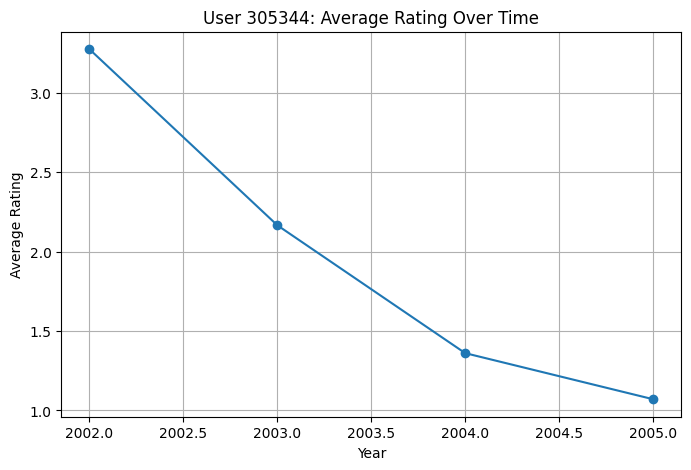

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

yearly_avg = pd.DataFrame({
    "year": sorted(user_year_ratings.keys()),
    "avg_rating": [
        np.mean(user_year_ratings[y])
        for y in sorted(user_year_ratings.keys())
    ]
})

plt.figure(figsize=(8,5))

plt.plot(
    yearly_avg["year"],
    yearly_avg["avg_rating"],
    marker="o"
)

plt.title(
    f"User {target_user}: Average Rating Over Time"
)

plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.grid(True)

plt.show()

Quantifying drift across the top 20 users

In [ ]:
from collections import defaultdict
import numpy as np
from scipy.stats import linregress

drift_results = []

top_user_ids = [
    user_id
    for user_id, _ in top_users
]

for target_user in top_user_ids:

    user_year_ratings = defaultdict(list)

    current_movie = None

    for file in files:

        with open(file, "r") as f:

            for line in f:

                line = line.strip()

                if line.endswith(":"):
                    current_movie = int(line[:-1])

                else:

                    user_id, rating, date = line.split(",")

                    if int(user_id) == target_user:

                        year = int(date[:4])

                        user_year_ratings[year].append(
                            int(rating)
                        )

    years = sorted(user_year_ratings.keys())

    if len(years) >= 2:

        avg_ratings = [
            np.mean(user_year_ratings[y])
            for y in years
        ]

        slope, *_ = linregress(
            years,
            avg_ratings
        )

        drift_results.append(
            [target_user, slope]
        )

drift_df = pd.DataFrame(
    drift_results,
    columns=["user_id", "rating_trend"]
)

drift_df

,user_id,rating_trend
0,305344,-0.741438
1,387418,-0.146797
2,2439493,-0.542377
3,1461435,-0.103359
4,1639792,0.599896
5,1314869,-0.802299
6,2606799,-1.662989
7,1932594,-0.105912
8,2056022,-0.086769
9,1114324,-0.797469


Repeated User-Movie Pairs

In [ ]:
from collections import Counter

pair_counts = Counter()

current_movie = None

for file in files:

    with open(file, "r") as f:

        for line in f:

            line = line.strip()

            if line.endswith(":"):
                current_movie = int(line[:-1])

            else:

                user_id = int(line.split(",")[0])

                pair_counts[
                    (user_id, current_movie)
                ] += 1

repeated_pairs = sum(
    1 for count in pair_counts.values()
    if count > 1
)

print("Repeated User-Movie Pairs:", repeated_pairs)

In [ ]:
repeated_examples = [
    pair
    for pair, count in pair_counts.items()
    if count > 1
]

print("Examples:")
print(repeated_examples[:10])

User Coverage Analysis(Understand how active users are and assess the severity of the cold-start problem)

In [ ]:
print("Mean:", user_ratings.mean())
print("Median:", np.median(user_ratings))
print("Min:", user_ratings.min())
print("Max:", user_ratings.max())

print("\nPercentiles")

for p in [25,50,75,90,95,99]:
    print(
        f"{p}th percentile:",
        np.percentile(user_ratings,p)
    )

Cold Start Quantification

In [ ]:
less_than_10 = (
    user_ratings < 10
).sum()

percentage = (
    less_than_10 /
    len(user_ratings)
) * 100

print(
    f"Users with fewer than 10 ratings: {percentage:.2f}%"
)

Movie Coverage Analysis(Understand popularity concentration and long-tail behavior)

In [ ]:
print("Mean:", movie_ratings.mean())
print("Median:", np.median(movie_ratings))
print("Min:", movie_ratings.min())
print("Max:", movie_ratings.max())

print("\nPercentiles")

for p in [25,50,75,90,95,99]:
    print(
        f"{p}th percentile:",
        np.percentile(movie_ratings,p)
    )

Long Tail Concentration

In [ ]:
sorted_movies = np.sort(movie_ratings)[::-1]

top_10_percent = int(
    0.10 * len(sorted_movies)
)

ratings_top_movies = (
    sorted_movies[:top_10_percent].sum()
)

all_ratings = sorted_movies.sum()

print(
    "Percentage of ratings belonging to top 10% movies:",
    round(
        100 * ratings_top_movies / all_ratings,
        2
    ),
    "%"
)

Summary Cell

In [ ]:
positive = (
    drift_df["rating_trend"] > 0
).sum()

negative = (
    drift_df["rating_trend"] < 0
).sum()

print(
    "Users becoming more generous:",
    positive
)

print(
    "Users becoming stricter:",
    negative
)

print(
    "Average slope:",
    drift_df["rating_trend"].mean()
)

Movie Release Year vs Rating Activity(Understand whether user interactions concentrate on older or newer movies)

In [ ]:
movie_activity = Counter()

current_movie = None

with open("combined_data_1.txt","r") as f:

    for line in f:

        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])

        else:
            movie_activity[current_movie] += 1

activity_df = pd.DataFrame(
    movie_activity.items(),
    columns=[
        "movie_id",
        "num_ratings"
    ]
)

movie_year_analysis = (
    activity_df
    .merge(
        movies,
        on="movie_id",
        how="left"
    )
)

movie_year_analysis.head()

Year-wise Activity

In [ ]:
year_activity = (
    movie_year_analysis
    .groupby("year")["num_ratings"]
    .sum()
    .reset_index()
)

year_activity

Plot

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    year_activity["year"],
    year_activity["num_ratings"]
)

plt.title(
    "Rating Activity by Movie Release Year"
)

plt.xlabel(
    "Release Year"
)

plt.ylabel(
    "Number of Ratings"
)

plt.grid(True)

plt.show()